## Import the Necessary libraries


In [3]:
!pip install geopandas shapely pyproj matplotlib


  Using cached geopandas-1.1.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.2 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached geopandas-1.1.1-py3-none-any.whl (338 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 941.3 kB/s eta 0:00:000:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 779.6 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 797.5 kB/s eta 0:00:0000:0100:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 712.4 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3

In [5]:
# Pip install everything needed to run pytorch and other deep learning modules
!pip install torch

  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached MarkupSafe-3.0.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (4.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 MB 2.0 MB/s eta 0:00:0000:0100:02
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached filelock-3.18.0-py3-none-any.whl (16 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [torch]32m7/8 [torch]]x]


In [149]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
import pyproj


In [75]:
# Show where the PROJ file is set
print(pyproj.datadir.get_data_dir())


/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/pyproj/proj_dir/share/proj


In [76]:
# Try setting the PROJ_LIB manually
# os.environ["PROJ_LIB"] = pyproj.datadir.get_data_dir()


In [77]:
# Unzip the file to the specified directory
# !unzip /Users/Christine.Muthee/Downloads/Dissagreg_maize.zip -d /Users/Christine.Muthee/Documents/AI4_small_farms_Viz/


In [150]:
# Read the shapefile as a GeoDataFrame
shapefile_path = '/Users/Christine.Muthee/Documents/AI4_small_farms_Viz/Dissagreg_maize/Maize_Intercropped.shp'
Intercropped = gpd.read_file(shapefile_path)
print(Intercropped.crs)  # Check the coordinate reference system
# # Display the first few rows of the GeoDataFrame
Intercropped.head()

EPSG:4326


,id,Survey_typ,main_crop,county,seasons_la,season_cod,seed_type,planting_w,Harvesting,Growing_da,...,CC_3,HASC_3,fid,strata,PLOTID,SAMPLEID,Shape_Leng,Shape_Area,layer,geometry
0,c70c74c4-0fd0-4262-8bd5-4b0194811508_63,recall_survey,Maize,Baringo,Long rains,MAM,Hybrid,06/04/2024,14/09/2024,161,...,809,NA,4.0,2.0,2606.0,2606.0,0.018004,0.00002,Baringo_Sample_Boxes,POINT (35.75185 0.06978)
1,5134f156-8baa-4761-a38d-d01419ec901c_72,recall_survey,Maize,Baringo,Long rains,MAM,Hybrid,16/03/2024,23/11/2024,252,...,810,NA,7.0,2.0,3451.0,3451.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.80034 -0.04073)
2,0ceda53e-a591-499e-9563-f76febb2e6f6_7,recall_survey,Maize,Baringo,Long rains,MAM,Hybrid,06/04/2024,14/09/2024,161,...,809,NA,8.0,3.0,3573.0,3573.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.81238 0.05788)
3,0e6d8660-1ecb-4564-a460-e5d0bf576e80_69,recall_survey,Maize,Baringo,Long rains,MAM,Hybrid,20/04/2024,26/10/2024,189,...,809,NA,9.0,3.0,3618.0,3618.0,0.018004,0.00002,Baringo_Sample_Boxes,POINT (35.74722 0.02528)
4,f0ca2550-1539-4517-9346-14d78ff51d8c_75,recall_survey,Maize,Baringo,Long rains,MAM,Hybrid,27/04/2024,12/10/2024,168,...,809,NA,10.0,3.0,3625.0,3625.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.79718 0.05074)


In [79]:
# Check the columns in the GeoDataFrame
print(len(Intercropped.columns))

173


In [151]:
shapefile_path = '/Users/Christine.Muthee/Documents/AI4_small_farms_Viz/Dissagreg_maize/Maize_Pure_Stand.shp'
PureStand = gpd.read_file(shapefile_path)
# Display the first few rows of the GeoDataFrame
PureStand.head()

,id,Survey_typ,main_crop,county,seasons_la,season_cod,seed_type,planting_w,Harvesting,Growing_da,...,CC_3,HASC_3,fid,strata,PLOTID,SAMPLEID,Shape_Leng,Shape_Area,layer,geometry
0,38e5c426-639a-42fe-a080-a655819faa0b_93,recall_survey,Maize,Baringo,Long rains,MAM,Hybrid,09/03/2024,16/11/2024,252,...,808,NA,1.0,2.0,2340.0,2340.0,0.018001,0.00002,Baringo_Sample_Boxes,POINT (35.56791 0.01637)
1,2e81f162-b32f-46c7-8413-1f6a5fb68527_94,recall_survey,Maize,Baringo,Long rains,MAM,Improved,30/03/2024,30/11/2024,245,...,808,NA,1.0,2.0,2340.0,2340.0,0.018001,0.00002,Baringo_Sample_Boxes,POINT (35.56861 0.01947)
2,a4d85dfa-741a-4844-9bed-286d9081f098_82,recall_survey,Maize,Baringo,Long rains,MAM,Hybrid,13/04/2024,23/11/2024,224,...,806,NA,2.0,2.0,2353.0,2353.0,0.018002,0.00002,Baringo_Sample_Boxes,POINT (35.6387 0.1656)
3,f02f0246-6019-474f-94fc-a901cb5b2fa1_84,recall_survey,Maize,Baringo,Long rains,MAM,Hybrid,09/03/2024,14/12/2024,280,...,806,NA,2.0,2.0,2353.0,2353.0,0.018002,0.00002,Baringo_Sample_Boxes,POINT (35.63941 0.16747)
4,523296d9-568f-44bf-88ee-01e36c776910_83,recall_survey,Maize,Baringo,Long rains,MAM,Hybrid,09/03/2024,07/12/2024,273,...,806,NA,3.0,2.0,2391.0,2391.0,0.018002,0.00002,Baringo_Sample_Boxes,POINT (35.63664 0.16804)


In [152]:
# check the columns in the GeoDataFrame
print(len(PureStand.columns))

173


#### We have 173 features including the geometric features in both inter cropped and pure stand dataset

In [153]:
print("Columns in Intercropped GeoDataFrame:")
print(Intercropped.columns)
print("Columns in Pure Stand GeoDataFrame:")
print(PureStand.columns)

Columns in Intercropped GeoDataFrame:
Index(['id', 'Survey_typ', 'main_crop', 'county', 'seasons_la', 'season_cod',
       'seed_type', 'planting_w', 'Harvesting', 'Growing_da',
       ...
       'CC_3', 'HASC_3', 'fid', 'strata', 'PLOTID', 'SAMPLEID', 'Shape_Leng',
       'Shape_Area', 'layer', 'geometry'],
      dtype='object', length=173)
Columns in Pure Stand GeoDataFrame:
Index(['id', 'Survey_typ', 'main_crop', 'county', 'seasons_la', 'season_cod',
       'seed_type', 'planting_w', 'Harvesting', 'Growing_da',
       ...
       'CC_3', 'HASC_3', 'fid', 'strata', 'PLOTID', 'SAMPLEID', 'Shape_Leng',
       'Shape_Area', 'layer', 'geometry'],
      dtype='object', length=173)


In [154]:
# Look at the crop variety in boith intercropped and pure stand dataset
print("Intercropped Crop Variety:", Intercropped['main_crop'].unique())
print("Pure Stand Crop Variety:", PureStand['main_crop'].unique())

Intercropped Crop Variety: ['Maize']
Pure Stand Crop Variety: ['Maize']


## Data Wrangling and Cleaning

In [155]:
# Drop columns where all values are NaN
print("Before:", Intercropped.columns.tolist())
print("Before:", PureStand.columns.tolist())
Intercropped = Intercropped.dropna(axis=1, how='all')
PureStand = PureStand.dropna(axis=1, how='all')
print("After:", Intercropped.columns.tolist())
print("After:", PureStand.columns.tolist())

Before: ['id', 'Survey_typ', 'main_crop', 'county', 'seasons_la', 'season_cod', 'seed_type', 'planting_w', 'Harvesting', 'Growing_da', 'Planting_m', 'second_cro', 'third_crop', 'type_of_fa', 'planted_ar', 'harvested_', 'overall_co', 'harvested', 'latitude', 'longitude', 'altitude_(', 'accuracy_(', 'estimated_', 'Crop_cut_d', 'latitude_5', 'longitude_', 'altitude_5', 'accuracy_1', 'photo_5*5_', 'no._of_cro', 'weight_kg_', 'average_WE', 'average__1', 'moisture_m', 'moisture_c', 'estimate_1', 'estimate_2', 'estimate_3', 'total_harv', 'estimate_4', '50_kg_per_', '90_kg_per_', 'Calculate', 'C31b. What', 'C32. If NO', 'C33. What', 'Calculat_1', 'C34. What', 'Calculat_2', 'C35. What', 'Calculat_3', 'C36. What', 'Calculat_4', 'C37. What', 'Calculat_5', 'C38. What', 'C39. How w', 'D1. Was an', 'D2. Which', 'CAN', 'DAP', 'TSP', 'urea', 'mavuno_pla', 'mavuno_top', 'baraka_pla', 'organic_ma', 'organic_li', 'herbicides', 'insecticid', 'fungicides', 'super_phos', 'D2. Whic_1', 'D2. Whic_2', 'other_i

In [85]:
# check the length of the columns in both datasets
print("Number of columns in Intercropped GeoDataFrame:", len(Intercropped.columns))
print("Number of columns in Pure Stand GeoDataFrame:", len(PureStand.columns))

Number of columns in Intercropped GeoDataFrame: 142
Number of columns in Pure Stand GeoDataFrame: 140


In [156]:
Intercropped = Intercropped.drop(columns=["estimate_1","estimate_2", "estimate_3"])
PureStand = PureStand.drop(columns=["estimate_1","estimate_2", "estimate_3"])


In [157]:
print(Intercropped.columns.tolist())
print(PureStand.columns.tolist())

['id', 'Survey_typ', 'main_crop', 'county', 'seasons_la', 'season_cod', 'seed_type', 'planting_w', 'Harvesting', 'Growing_da', 'Planting_m', 'second_cro', 'third_crop', 'type_of_fa', 'planted_ar', 'harvested_', 'overall_co', 'harvested', 'latitude', 'longitude', 'altitude_(', 'accuracy_(', 'estimated_', 'moisture_m', 'moisture_c', 'estimate_4', '50_kg_per_', '90_kg_per_', 'C32. If NO', 'C33. What', 'Calculat_1', 'C39. How w', 'D1. Was an', 'D2. Which', 'CAN', 'DAP', 'TSP', 'urea', 'mavuno_pla', 'mavuno_top', 'baraka_pla', 'organic_ma', 'organic_li', 'herbicides', 'insecticid', 'fungicides', 'super_phos', 'D2. Whic_1', 'D2. Whic_2', 'other_inpu', 'CAN_supply', 'quantity_o', 'quantity_1', 'source_of_', 'DAP_supply', 'quantity_2', 'quantity_3', 'source_o_1', 'urea_suppl', 'quantity_4', 'quantity_5', 'field_88', 'quantity_6', 'quantity_7', 'source_o_3', 'mavuno_t_1', 'quantity_8', 'quantity_9', 'source_o_4', 'baraka_p_1', 'quantity10', 'quantity11', 'organic__1', 'quantity12', 'quantity13'

In [158]:
print("Number of columns in Intercropped GeoDataFrame:", len(Intercropped.columns))
print("Number of columns in Pure Stand GeoDataFrame:", len(PureStand.columns))

Number of columns in Intercropped GeoDataFrame: 139
Number of columns in Pure Stand GeoDataFrame: 137


In [159]:
# Check the percentage of missing values in each column
print("Intercropped GeoDataFrame missing values percentage:")
print(Intercropped.isnull().mean() * 100)
print("Pure Stand GeoDataFrame missing values percentage:")
print(PureStand.isnull().mean() * 100)


Intercropped GeoDataFrame missing values percentage:
id            0.000000
Survey_typ    0.000000
main_crop     0.000000
county        0.000000
seasons_la    0.088574
                ...   
SAMPLEID      4.960142
Shape_Leng    4.960142
Shape_Area    4.960142
layer         4.960142
geometry      0.000000
Length: 139, dtype: float64
Pure Stand GeoDataFrame missing values percentage:
id             0.000000
Survey_typ     0.000000
main_crop      0.000000
county         0.000000
seasons_la     0.208420
                ...    
SAMPLEID      12.713631
Shape_Leng    12.713631
Shape_Area    12.713631
layer         12.713631
geometry       0.000000
Length: 137, dtype: float64


In [160]:
# create a class called class_label with the crop types 
# Build list of crops per sample (no duplication!)
Intercropped["crop_list"] = Intercropped[["main_crop", "second_cro", "third_crop"]].values.tolist()
Intercropped["crop_list"] = Intercropped["crop_list"].apply(lambda crops: [c for c in crops if pd.notnull(c)])


In [161]:
Intercropped['crop_list']

0               [Maize, Beans]
1               [Maize, Beans]
2               [Maize, Beans]
3               [Maize, Beans]
4               [Maize, Beans]
                 ...          
1124            [Maize, Beans]
1125    [Maize, Finger Millet]
1126            [Maize, Beans]
1127                   [Maize]
1128     [Maize, Maize, Beans]
Name: crop_list, Length: 1129, dtype: object

In [162]:
# We can now safely drop the columns with the main, second and third crops
Intercropped = Intercropped.drop(columns=["main_crop", "second_cro", "third_crop"])
# Rename the main crop to crop_list
PureStand = PureStand.rename(columns={"main_crop": "crop_list"})

In [163]:
# After creating a crop list as the class label
print("Created crop list as class label:")
print(Intercropped.columns.tolist())
print(PureStand.columns.tolist())

Created crop list as class label:
['id', 'Survey_typ', 'county', 'seasons_la', 'season_cod', 'seed_type', 'planting_w', 'Harvesting', 'Growing_da', 'Planting_m', 'type_of_fa', 'planted_ar', 'harvested_', 'overall_co', 'harvested', 'latitude', 'longitude', 'altitude_(', 'accuracy_(', 'estimated_', 'moisture_m', 'moisture_c', 'estimate_4', '50_kg_per_', '90_kg_per_', 'C32. If NO', 'C33. What', 'Calculat_1', 'C39. How w', 'D1. Was an', 'D2. Which', 'CAN', 'DAP', 'TSP', 'urea', 'mavuno_pla', 'mavuno_top', 'baraka_pla', 'organic_ma', 'organic_li', 'herbicides', 'insecticid', 'fungicides', 'super_phos', 'D2. Whic_1', 'D2. Whic_2', 'other_inpu', 'CAN_supply', 'quantity_o', 'quantity_1', 'source_of_', 'DAP_supply', 'quantity_2', 'quantity_3', 'source_o_1', 'urea_suppl', 'quantity_4', 'quantity_5', 'field_88', 'quantity_6', 'quantity_7', 'source_o_3', 'mavuno_t_1', 'quantity_8', 'quantity_9', 'source_o_4', 'baraka_p_1', 'quantity10', 'quantity11', 'organic__1', 'quantity12', 'quantity13', 'orga

In [164]:
# Print those with more than 50% missing values
print("Intercropped GeoDataFrame columns with more than 50% missing values:")
print(Intercropped.columns[Intercropped.isnull().mean() > 0.5])
print("Pure Stand GeoDataFrame columns with more than 50% missing values:")
print(PureStand.columns[PureStand.isnull().mean() > 0.5])

Intercropped GeoDataFrame columns with more than 50% missing values:
Index(['C32. If NO', 'C33. What', 'Calculat_1', 'other_inpu', 'source_of_',
       'source_o_1', 'urea_suppl', 'quantity_4', 'quantity_5', 'field_88',
       'quantity_6', 'quantity_7', 'source_o_3', 'mavuno_t_1', 'quantity_8',
       'quantity_9', 'source_o_4', 'baraka_p_1', 'quantity10', 'quantity11',
       'organic__1', 'quantity12', 'quantity13', 'organic__2', 'quantity14',
       'quantity15', 'herbicide_', 'quantity16', 'quantity17', 'insectic_1',
       'quantity18', 'quantity19', 'fungicide_', 'quantity20', 'quantity21',
       'Superphosp', 'quantity22', 'quantity23', 'Reasons_fo', 'other_fact',
       'pest_and_d', 'pest_and_1', 'pest_and_2', 'pest_and_3', 'pest_and_4'],
      dtype='object')
Pure Stand GeoDataFrame columns with more than 50% missing values:
Index(['C32. If NO', 'C33. What', 'Calculat_1', 'other_inpu', 'CAN_supply',
       'quantity_o', 'quantity_1', 'source_of_', 'source_o_1', 'urea_suppl'

In [165]:
# Those with more than 80% missing values
print("Intercropped GeoDataFrame columns with more than 80% missing values:")
print(Intercropped.columns[Intercropped.isnull().mean() > 0.8])
print("Pure Stand GeoDataFrame columns with more than 80% missing values:")
print(PureStand.columns[PureStand.isnull().mean() > 0.8])

Intercropped GeoDataFrame columns with more than 80% missing values:
Index(['C33. What', 'Calculat_1', 'other_inpu', 'source_of_', 'source_o_1',
       'urea_suppl', 'quantity_4', 'quantity_5', 'field_88', 'quantity_6',
       'quantity_7', 'source_o_3', 'mavuno_t_1', 'quantity_8', 'quantity_9',
       'source_o_4', 'baraka_p_1', 'quantity10', 'quantity11', 'organic__1',
       'quantity12', 'quantity13', 'organic__2', 'quantity14', 'quantity15',
       'herbicide_', 'quantity16', 'quantity17', 'insectic_1', 'quantity18',
       'quantity19', 'fungicide_', 'quantity20', 'quantity21', 'Superphosp',
       'quantity22', 'quantity23', 'Reasons_fo', 'other_fact', 'pest_and_1',
       'pest_and_2', 'pest_and_3', 'pest_and_4'],
      dtype='object')
Pure Stand GeoDataFrame columns with more than 80% missing values:
Index(['C32. If NO', 'C33. What', 'Calculat_1', 'other_inpu', 'source_of_',
       'source_o_1', 'urea_suppl', 'quantity_4', 'quantity_5', 'field_88',
       'quantity_6', 'quanti

In [166]:
# Drop columns with more than 80% missing values
Intercropped = Intercropped.drop(columns=Intercropped.columns[Intercropped.isnull().mean() > 0.8])
PureStand = PureStand.drop(columns=PureStand.columns[PureStand.isnull().mean() > 0.8])

In [167]:
print("Number of columns in Intercropped GeoDataFrame:", len(Intercropped.columns))
print("Number of columns in Pure Stand GeoDataFrame:", len(PureStand.columns))

Number of columns in Intercropped GeoDataFrame: 94
Number of columns in Pure Stand GeoDataFrame: 93


In [168]:
# Check the percentage of missing values in each column
print("Intercropped GeoDataFrame missing values percentage:")
print(Intercropped.columns[Intercropped.isnull().mean() > 0.6])
print("Pure Stand GeoDataFrame missing values percentage:")
print(PureStand.columns[PureStand.isnull().mean() > 0.6])

Intercropped GeoDataFrame missing values percentage:
Index(['C32. If NO'], dtype='object')
Pure Stand GeoDataFrame missing values percentage:
Index(['CAN_supply', 'quantity_o', 'quantity_1'], dtype='object')


In [169]:
# Drop 'C32. If NO' column
Intercropped = Intercropped.drop(columns=["C32. If NO"])

In [170]:
# List the columns again
print("After dropping Columns with >80 % Null Values:\n", Intercropped.columns.tolist())
print("After dropping Columns with >80 % Null Values:\n", PureStand.columns.tolist())

After dropping Columns with >80 % Null Values:
 ['id', 'Survey_typ', 'county', 'seasons_la', 'season_cod', 'seed_type', 'planting_w', 'Harvesting', 'Growing_da', 'Planting_m', 'type_of_fa', 'planted_ar', 'harvested_', 'overall_co', 'harvested', 'latitude', 'longitude', 'altitude_(', 'accuracy_(', 'estimated_', 'moisture_m', 'moisture_c', 'estimate_4', '50_kg_per_', '90_kg_per_', 'C39. How w', 'D1. Was an', 'D2. Which', 'CAN', 'DAP', 'TSP', 'urea', 'mavuno_pla', 'mavuno_top', 'baraka_pla', 'organic_ma', 'organic_li', 'herbicides', 'insecticid', 'fungicides', 'super_phos', 'D2. Whic_1', 'D2. Whic_2', 'CAN_supply', 'quantity_o', 'quantity_1', 'DAP_supply', 'quantity_2', 'quantity_3', 'hazards_af', 'hail_stone', 'flooding', 'pests_dise', 'drought', 'dry_spell', 'late_onset', 'early_cess', 'D7. Select', 'D7. Sele_1', 'pest_and_d', '_index', '_parent_ta', '_parent_in', '_submissio', '_submiss_1', '_submiss_2', '_submiss_4', '_unique_id', 'GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NA

In [171]:
print("Before:", Intercropped.columns.tolist())
print("Before:", PureStand.columns.tolist())
Intercropped = Intercropped.dropna(axis=1, how='all')
PureStand = PureStand.dropna(axis=1, how='all')
print("After:", Intercropped.columns.tolist())
print("After:", PureStand.columns.tolist())

Before: ['id', 'Survey_typ', 'county', 'seasons_la', 'season_cod', 'seed_type', 'planting_w', 'Harvesting', 'Growing_da', 'Planting_m', 'type_of_fa', 'planted_ar', 'harvested_', 'overall_co', 'harvested', 'latitude', 'longitude', 'altitude_(', 'accuracy_(', 'estimated_', 'moisture_m', 'moisture_c', 'estimate_4', '50_kg_per_', '90_kg_per_', 'C39. How w', 'D1. Was an', 'D2. Which', 'CAN', 'DAP', 'TSP', 'urea', 'mavuno_pla', 'mavuno_top', 'baraka_pla', 'organic_ma', 'organic_li', 'herbicides', 'insecticid', 'fungicides', 'super_phos', 'D2. Whic_1', 'D2. Whic_2', 'CAN_supply', 'quantity_o', 'quantity_1', 'DAP_supply', 'quantity_2', 'quantity_3', 'hazards_af', 'hail_stone', 'flooding', 'pests_dise', 'drought', 'dry_spell', 'late_onset', 'early_cess', 'D7. Select', 'D7. Sele_1', 'pest_and_d', '_index', '_parent_ta', '_parent_in', '_submissio', '_submiss_1', '_submiss_2', '_submiss_4', '_unique_id', 'GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2', 'NAME_2', 'NL_NAME_2', '

In [172]:
print("Number of columns in Intercropped GeoDataFrame:", len(Intercropped.columns))
print("Number of columns in Pure Stand GeoDataFrame:", len(PureStand.columns))

Number of columns in Intercropped GeoDataFrame: 93
Number of columns in Pure Stand GeoDataFrame: 93


### Columns are now similar, Ready to merge dataset for training

In [173]:
Intercropped.head()

,id,Survey_typ,county,seasons_la,season_cod,seed_type,planting_w,Harvesting,Growing_da,Planting_m,...,HASC_3,fid,strata,PLOTID,SAMPLEID,Shape_Leng,Shape_Area,layer,geometry,crop_list
0,c70c74c4-0fd0-4262-8bd5-4b0194811508_63,recall_survey,Baringo,Long rains,MAM,Hybrid,06/04/2024,14/09/2024,161,Intercropping,...,NA,4.0,2.0,2606.0,2606.0,0.018004,0.00002,Baringo_Sample_Boxes,POINT (35.75185 0.06978),"[Maize, Beans]"
1,5134f156-8baa-4761-a38d-d01419ec901c_72,recall_survey,Baringo,Long rains,MAM,Hybrid,16/03/2024,23/11/2024,252,Intercropping,...,NA,7.0,2.0,3451.0,3451.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.80034 -0.04073),"[Maize, Beans]"
2,0ceda53e-a591-499e-9563-f76febb2e6f6_7,recall_survey,Baringo,Long rains,MAM,Hybrid,06/04/2024,14/09/2024,161,Intercropping,...,NA,8.0,3.0,3573.0,3573.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.81238 0.05788),"[Maize, Beans]"
3,0e6d8660-1ecb-4564-a460-e5d0bf576e80_69,recall_survey,Baringo,Long rains,MAM,Hybrid,20/04/2024,26/10/2024,189,Intercropping,...,NA,9.0,3.0,3618.0,3618.0,0.018004,0.00002,Baringo_Sample_Boxes,POINT (35.74722 0.02528),"[Maize, Beans]"
4,f0ca2550-1539-4517-9346-14d78ff51d8c_75,recall_survey,Baringo,Long rains,MAM,Hybrid,27/04/2024,12/10/2024,168,Intercropping,...,NA,10.0,3.0,3625.0,3625.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.79718 0.05074),"[Maize, Beans]"


In [174]:
PureStand.head()
#Take crop_list column to the end of the DataFrame 
PureStand = PureStand[[col for col in PureStand.columns if col != 'crop_list']+['crop_list'] ]
PureStand.head()

,id,Survey_typ,county,seasons_la,season_cod,seed_type,planting_w,Harvesting,Growing_da,Planting_m,...,HASC_3,fid,strata,PLOTID,SAMPLEID,Shape_Leng,Shape_Area,layer,geometry,crop_list
0,38e5c426-639a-42fe-a080-a655819faa0b_93,recall_survey,Baringo,Long rains,MAM,Hybrid,09/03/2024,16/11/2024,252,Pure stand,...,NA,1.0,2.0,2340.0,2340.0,0.018001,0.00002,Baringo_Sample_Boxes,POINT (35.56791 0.01637),Maize
1,2e81f162-b32f-46c7-8413-1f6a5fb68527_94,recall_survey,Baringo,Long rains,MAM,Improved,30/03/2024,30/11/2024,245,Pure stand,...,NA,1.0,2.0,2340.0,2340.0,0.018001,0.00002,Baringo_Sample_Boxes,POINT (35.56861 0.01947),Maize
2,a4d85dfa-741a-4844-9bed-286d9081f098_82,recall_survey,Baringo,Long rains,MAM,Hybrid,13/04/2024,23/11/2024,224,Pure stand,...,NA,2.0,2.0,2353.0,2353.0,0.018002,0.00002,Baringo_Sample_Boxes,POINT (35.6387 0.1656),Maize
3,f02f0246-6019-474f-94fc-a901cb5b2fa1_84,recall_survey,Baringo,Long rains,MAM,Hybrid,09/03/2024,14/12/2024,280,Pure stand,...,NA,2.0,2.0,2353.0,2353.0,0.018002,0.00002,Baringo_Sample_Boxes,POINT (35.63941 0.16747),Maize
4,523296d9-568f-44bf-88ee-01e36c776910_83,recall_survey,Baringo,Long rains,MAM,Hybrid,09/03/2024,07/12/2024,273,Pure stand,...,NA,3.0,2.0,2391.0,2391.0,0.018002,0.00002,Baringo_Sample_Boxes,POINT (35.63664 0.16804),Maize


##### Check for Duplicated columns

In [175]:

# Get all rows other than the last rows in a dataframe
Intercropped_che = Intercropped.iloc[:, :-1].T.duplicated()
print("Duplicated columns in Intercropped GeoDataFrame:", Intercropped.iloc[:, :-1].columns[Intercropped_che])

Duplicated columns in Intercropped GeoDataFrame: Index(['super_phos', 'NL_NAME_2', 'VARNAME_3', 'NL_NAME_3', 'ENGTYPE_3',
       'HASC_3', 'SAMPLEID'],
      dtype='object')


In [176]:
# Duplicated columns in Pure stand
PureStand_che = PureStand.T.duplicated()
PureStand_duplicated_columns = PureStand.columns[PureStand_che]
print("Duplicated columns in Pure Stand GeoDataFrame:", PureStand_duplicated_columns)

Duplicated columns in Pure Stand GeoDataFrame: Index(['NL_NAME_2', 'VARNAME_3', 'NL_NAME_3', 'ENGTYPE_3', 'HASC_3',
       'SAMPLEID'],
      dtype='object')


In [177]:
# Drop Duplicated columns in Intercropped and Pure Stand
columns_to_drop = ['NL_NAME_2', 'VARNAME_3', 'NL_NAME_3', 'ENGTYPE_3', 'HASC_3', 'SAMPLEID','D2.Which']
Intercropped = Intercropped.drop(columns=columns_to_drop, errors='ignore')
PureStand = PureStand.drop(columns=columns_to_drop, errors='ignore')

In [178]:
print("Number of columns in Intercropped GeoDataFrame:", len(Intercropped.columns))
print("Number of columns in Pure Stand GeoDataFrame:", len(PureStand.columns))

Number of columns in Intercropped GeoDataFrame: 87
Number of columns in Pure Stand GeoDataFrame: 87


In [179]:
# Create a column called "plant_to_harvest" that gets the period between planting and harvesting.
# This will need us to covert the planting and harvesting dates to datetime format and then get the difference 
Intercropped['planting_w'] = pd.to_datetime(Intercropped['planting_w'], errors='coerce')
Intercropped['Harvesting'] = pd.to_datetime(Intercropped['Harvesting'], errors='coerce')
Intercropped['plant_to_harvest'] = (Intercropped['Harvesting'] - Intercropped['planting_w']).dt.days
Intercropped['plant_to_harvest'] = Intercropped['plant_to_harvest'].fillna(0).astype(int)
Intercropped.head()

/var/folders/bx/hv5n07d907v5njq13q00z2880000gq/T/ipykernel_14606/263389092.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  Intercropped['Harvesting'] = pd.to_datetime(Intercropped['Harvesting'], errors='coerce')


,id,Survey_typ,county,seasons_la,season_cod,seed_type,planting_w,Harvesting,Growing_da,Planting_m,...,CC_3,fid,strata,PLOTID,Shape_Leng,Shape_Area,layer,geometry,crop_list,plant_to_harvest
0,c70c74c4-0fd0-4262-8bd5-4b0194811508_63,recall_survey,Baringo,Long rains,MAM,Hybrid,2024-06-04,2024-09-14,161,Intercropping,...,809,4.0,2.0,2606.0,0.018004,0.00002,Baringo_Sample_Boxes,POINT (35.75185 0.06978),"[Maize, Beans]",102
1,5134f156-8baa-4761-a38d-d01419ec901c_72,recall_survey,Baringo,Long rains,MAM,Hybrid,NaT,2024-11-23,252,Intercropping,...,810,7.0,2.0,3451.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.80034 -0.04073),"[Maize, Beans]",0
2,0ceda53e-a591-499e-9563-f76febb2e6f6_7,recall_survey,Baringo,Long rains,MAM,Hybrid,2024-06-04,2024-09-14,161,Intercropping,...,809,8.0,3.0,3573.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.81238 0.05788),"[Maize, Beans]",102
3,0e6d8660-1ecb-4564-a460-e5d0bf576e80_69,recall_survey,Baringo,Long rains,MAM,Hybrid,NaT,2024-10-26,189,Intercropping,...,809,9.0,3.0,3618.0,0.018004,0.00002,Baringo_Sample_Boxes,POINT (35.74722 0.02528),"[Maize, Beans]",0
4,f0ca2550-1539-4517-9346-14d78ff51d8c_75,recall_survey,Baringo,Long rains,MAM,Hybrid,NaT,2024-10-12,168,Intercropping,...,809,10.0,3.0,3625.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.79718 0.05074),"[Maize, Beans]",0


In [180]:
# dO THE SAME FOR Pure Stand
PureStand['planting_w'] = pd.to_datetime(PureStand['planting_w'], errors='coerce')
PureStand['Harvesting'] = pd.to_datetime(PureStand['Harvesting'], errors='coerce')
PureStand['plant_to_harvest'] = (PureStand['Harvesting'] - PureStand['planting_w']).dt.days
PureStand['plant_to_harvest'] = PureStand['plant_to_harvest'].fillna(0).astype(int)
PureStand.head()

/var/folders/bx/hv5n07d907v5njq13q00z2880000gq/T/ipykernel_14606/333675153.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  PureStand['Harvesting'] = pd.to_datetime(PureStand['Harvesting'], errors='coerce')


,id,Survey_typ,county,seasons_la,season_cod,seed_type,planting_w,Harvesting,Growing_da,Planting_m,...,CC_3,fid,strata,PLOTID,Shape_Leng,Shape_Area,layer,geometry,crop_list,plant_to_harvest
0,38e5c426-639a-42fe-a080-a655819faa0b_93,recall_survey,Baringo,Long rains,MAM,Hybrid,2024-09-03,2024-11-16,252,Pure stand,...,808,1.0,2.0,2340.0,0.018001,0.00002,Baringo_Sample_Boxes,POINT (35.56791 0.01637),Maize,74
1,2e81f162-b32f-46c7-8413-1f6a5fb68527_94,recall_survey,Baringo,Long rains,MAM,Improved,NaT,2024-11-30,245,Pure stand,...,808,1.0,2.0,2340.0,0.018001,0.00002,Baringo_Sample_Boxes,POINT (35.56861 0.01947),Maize,0
2,a4d85dfa-741a-4844-9bed-286d9081f098_82,recall_survey,Baringo,Long rains,MAM,Hybrid,NaT,2024-11-23,224,Pure stand,...,806,2.0,2.0,2353.0,0.018002,0.00002,Baringo_Sample_Boxes,POINT (35.6387 0.1656),Maize,0
3,f02f0246-6019-474f-94fc-a901cb5b2fa1_84,recall_survey,Baringo,Long rains,MAM,Hybrid,2024-09-03,2024-12-14,280,Pure stand,...,806,2.0,2.0,2353.0,0.018002,0.00002,Baringo_Sample_Boxes,POINT (35.63941 0.16747),Maize,102
4,523296d9-568f-44bf-88ee-01e36c776910_83,recall_survey,Baringo,Long rains,MAM,Hybrid,2024-09-03,2024-12-07,273,Pure stand,...,806,3.0,2.0,2391.0,0.018002,0.00002,Baringo_Sample_Boxes,POINT (35.63664 0.16804),Maize,95


### Merge Data and prepare it for training

In [181]:
# Merge the two datasets
merged_data = pd.concat([Intercropped, PureStand], ignore_index=True)
print("Merged DataFrame shape:", merged_data.shape)

Merged DataFrame shape: (3528, 88)


In [182]:
merged_data.head()

,id,Survey_typ,county,seasons_la,season_cod,seed_type,planting_w,Harvesting,Growing_da,Planting_m,...,CC_3,fid,strata,PLOTID,Shape_Leng,Shape_Area,layer,geometry,crop_list,plant_to_harvest
0,c70c74c4-0fd0-4262-8bd5-4b0194811508_63,recall_survey,Baringo,Long rains,MAM,Hybrid,2024-06-04,2024-09-14,161,Intercropping,...,809,4.0,2.0,2606.0,0.018004,0.00002,Baringo_Sample_Boxes,POINT (35.75185 0.06978),"[Maize, Beans]",102
1,5134f156-8baa-4761-a38d-d01419ec901c_72,recall_survey,Baringo,Long rains,MAM,Hybrid,NaT,2024-11-23,252,Intercropping,...,810,7.0,2.0,3451.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.80034 -0.04073),"[Maize, Beans]",0
2,0ceda53e-a591-499e-9563-f76febb2e6f6_7,recall_survey,Baringo,Long rains,MAM,Hybrid,2024-06-04,2024-09-14,161,Intercropping,...,809,8.0,3.0,3573.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.81238 0.05788),"[Maize, Beans]",102
3,0e6d8660-1ecb-4564-a460-e5d0bf576e80_69,recall_survey,Baringo,Long rains,MAM,Hybrid,NaT,2024-10-26,189,Intercropping,...,809,9.0,3.0,3618.0,0.018004,0.00002,Baringo_Sample_Boxes,POINT (35.74722 0.02528),"[Maize, Beans]",0
4,f0ca2550-1539-4517-9346-14d78ff51d8c_75,recall_survey,Baringo,Long rains,MAM,Hybrid,NaT,2024-10-12,168,Intercropping,...,809,10.0,3.0,3625.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.79718 0.05074),"[Maize, Beans]",0


In [183]:
# Percentage of Missing Values in the Merged DataFrame
missing_percentage = merged_data.isnull().mean() * 100
missing_percentage
# print(f"Percentage of Missing Values in Merged DataFrame: {missing_percentage}")


id                   0.000000
Survey_typ           0.000000
county               0.000000
seasons_la           0.170068
season_cod           0.170068
                      ...    
Shape_Area          10.232426
layer               10.232426
geometry             0.000000
crop_list            0.000000
plant_to_harvest     0.000000
Length: 88, dtype: float64

In [184]:
# Drop the date columns that are not needed for training
merged_data = merged_data.drop(columns=["planting_w", "Harvesting"], errors='ignore')
print("Columns after dropping date columns:", merged_data.columns.tolist())

Columns after dropping date columns: ['id', 'Survey_typ', 'county', 'seasons_la', 'season_cod', 'seed_type', 'Growing_da', 'Planting_m', 'type_of_fa', 'planted_ar', 'harvested_', 'overall_co', 'harvested', 'latitude', 'longitude', 'altitude_(', 'accuracy_(', 'estimated_', 'moisture_m', 'moisture_c', 'estimate_4', '50_kg_per_', '90_kg_per_', 'C39. How w', 'D1. Was an', 'D2. Which', 'CAN', 'DAP', 'TSP', 'urea', 'mavuno_pla', 'mavuno_top', 'baraka_pla', 'organic_ma', 'organic_li', 'herbicides', 'insecticid', 'fungicides', 'super_phos', 'D2. Whic_1', 'D2. Whic_2', 'CAN_supply', 'quantity_o', 'quantity_1', 'DAP_supply', 'quantity_2', 'quantity_3', 'hazards_af', 'hail_stone', 'flooding', 'pests_dise', 'drought', 'dry_spell', 'late_onset', 'early_cess', 'D7. Select', 'D7. Sele_1', 'pest_and_d', '_index', '_parent_ta', '_parent_in', '_submissio', '_submiss_1', '_submiss_2', '_submiss_4', '_unique_id', 'GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2', 'NAME_2', 'NAME_3', 'TY

In [185]:
# Columns with missing values
print("Columns with missing values in Merged DataFrame:")
print(merged_data.columns[merged_data.isnull().any()])

Columns with missing values in Merged DataFrame:
Index(['seasons_la', 'season_cod', 'altitude_(', 'estimate_4', 'D2. Which',
       'CAN', 'DAP', 'TSP', 'urea', 'mavuno_pla', 'mavuno_top', 'baraka_pla',
       'organic_ma', 'organic_li', 'herbicides', 'insecticid', 'fungicides',
       'super_phos', 'D2. Whic_1', 'D2. Whic_2', 'CAN_supply', 'quantity_o',
       'quantity_1', 'DAP_supply', 'quantity_2', 'quantity_3', 'pest_and_d',
       '_index', 'fid', 'strata', 'PLOTID', 'Shape_Leng', 'Shape_Area',
       'layer'],
      dtype='object')


In [186]:
missing_percentage = merged_data.isnull().mean() * 100
missing_percentage

id                   0.000000
Survey_typ           0.000000
county               0.000000
seasons_la           0.170068
season_cod           0.170068
                      ...    
Shape_Area          10.232426
layer               10.232426
geometry             0.000000
crop_list            0.000000
plant_to_harvest     0.000000
Length: 86, dtype: float64

In [187]:
merged_data.columns.tolist()

['id',
 'Survey_typ',
 'county',
 'seasons_la',
 'season_cod',
 'seed_type',
 'Growing_da',
 'Planting_m',
 'type_of_fa',
 'planted_ar',
 'harvested_',
 'overall_co',
 'harvested',
 'latitude',
 'longitude',
 'altitude_(',
 'accuracy_(',
 'estimated_',
 'moisture_m',
 'moisture_c',
 'estimate_4',
 '50_kg_per_',
 '90_kg_per_',
 'C39. How w',
 'D1. Was an',
 'D2. Which',
 'CAN',
 'DAP',
 'TSP',
 'urea',
 'mavuno_pla',
 'mavuno_top',
 'baraka_pla',
 'organic_ma',
 'organic_li',
 'herbicides',
 'insecticid',
 'fungicides',
 'super_phos',
 'D2. Whic_1',
 'D2. Whic_2',
 'CAN_supply',
 'quantity_o',
 'quantity_1',
 'DAP_supply',
 'quantity_2',
 'quantity_3',
 'hazards_af',
 'hail_stone',
 'flooding',
 'pests_dise',
 'drought',
 'dry_spell',
 'late_onset',
 'early_cess',
 'D7. Select',
 'D7. Sele_1',
 'pest_and_d',
 '_index',
 '_parent_ta',
 '_parent_in',
 '_submissio',
 '_submiss_1',
 '_submiss_2',
 '_submiss_4',
 '_unique_id',
 'GID_3',
 'GID_0',
 'COUNTRY',
 'GID_1',
 'NAME_1',
 'NL_NAME_1'

In [188]:
# Drop a few columns that are not needed for training
columns_to_drop = [
    'D2. Whic_1',
    'D2. Whic_2',
    'CAN_supply',
    'quantity_o',
    'quantity_1',
    'DAP_supply',
    'quantity_2',
    'quantity_3',
    '_index',
    '_parent_ta',
    '_parent_in',
    '_submissio',
    '_submiss_1',
    '_submiss_2',
    '_submiss_4',
    '_unique_id',
    'GID_3',
    'GID_0',
    'COUNTRY',
    'GID_1',
    'NL_NAME_1']
merged_data = merged_data.drop(columns=columns_to_drop, errors='ignore')
merged_data.columns.tolist()
missing_percentage = merged_data.isnull().mean() * 100
missing_percentage

id                   0.000000
Survey_typ           0.000000
county               0.000000
seasons_la           0.170068
season_cod           0.170068
                      ...    
Shape_Area          10.232426
layer               10.232426
geometry             0.000000
crop_list            0.000000
plant_to_harvest     0.000000
Length: 65, dtype: float64

In [189]:
# # fill null values with zero in the fungicides,herbicites and insecticides columns
columns_to_fill = ['D2. Which',
                    'CAN',
                    'DAP',
                    'TSP',
                    'urea',
                    'mavuno_pla',
                    'mavuno_top',
                    'baraka_pla',
                    'organic_ma',
                    'organic_li',
                    'herbicides',
                    'insecticid',
                    'fungicides',
                    'super_phos'] #Made only 13% of the dataset
# Drop the rows where all values are NaN in the specified columns
merged_data = merged_data.dropna(subset=columns_to_fill, how='all')
two_cols =[ 'seasons_la','season_cod']
merged_data = merged_data.dropna(subset=two_cols, how='all')
# # Check the columns after filling null values
merged_data.dropna(subset=['estimate_4'], how='all', inplace=True)
missing_percentage = merged_data.isnull().mean() * 100
missing_percentage

id                   0.000000
Survey_typ           0.000000
county               0.000000
seasons_la           0.000000
season_cod           0.000000
                      ...    
Shape_Area          10.309682
layer               10.309682
geometry             0.000000
crop_list            0.000000
plant_to_harvest     0.000000
Length: 65, dtype: float64

In [190]:
# merged_data['altitude_(']
# Drop this column
merged_data = merged_data.drop(columns=["altitude_(m)"], errors='ignore') # Had date typed into the Altitute , No need to overthink
merged_data

,id,Survey_typ,county,seasons_la,season_cod,seed_type,Growing_da,Planting_m,type_of_fa,planted_ar,...,CC_3,fid,strata,PLOTID,Shape_Leng,Shape_Area,layer,geometry,crop_list,plant_to_harvest
0,c70c74c4-0fd0-4262-8bd5-4b0194811508_63,recall_survey,Baringo,Long rains,MAM,Hybrid,161,Intercropping,Rainfed,0.50,...,809,4.0,2.0,2606.0,0.018004,0.00002,Baringo_Sample_Boxes,POINT (35.75185 0.06978),"[Maize, Beans]",102
1,5134f156-8baa-4761-a38d-d01419ec901c_72,recall_survey,Baringo,Long rains,MAM,Hybrid,252,Intercropping,Rainfed,1.00,...,810,7.0,2.0,3451.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.80034 -0.04073),"[Maize, Beans]",0
3,0e6d8660-1ecb-4564-a460-e5d0bf576e80_69,recall_survey,Baringo,Long rains,MAM,Hybrid,189,Intercropping,Rainfed,1.25,...,809,9.0,3.0,3618.0,0.018004,0.00002,Baringo_Sample_Boxes,POINT (35.74722 0.02528),"[Maize, Beans]",0
4,f0ca2550-1539-4517-9346-14d78ff51d8c_75,recall_survey,Baringo,Long rains,MAM,Hybrid,168,Intercropping,Rainfed,1.00,...,809,10.0,3.0,3625.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.79718 0.05074),"[Maize, Beans]",0
5,b9de5fc5-2ee0-40bc-b706-22dfbcddc473_77,recall_survey,Baringo,Long rains,MAM,Hybrid,139,Intercropping,Rainfed,0.75,...,809,10.0,3.0,3625.0,0.018005,0.00002,Baringo_Sample_Boxes,POINT (35.79761 0.05073),"[Maize, Beans]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3523,75d3aa98-01bf-4f62-8f83-425e1598a8b2_464,recall_survey,Uasin Gishu,Long rains,MAM,Hybrid,238,Pure stand,Rainfed,1.00,...,709,NaN,NaN,NaN,NaN,NaN,None,POINT (35.04679 0.57983),Maize,0
3524,dffc4892-9ee0-4eab-a506-b5eba99a0bec_494,recall_survey,Uasin Gishu,Long rains,MAM,Hybrid,182,Pure stand,Rainfed,1.00,...,709,NaN,NaN,NaN,NaN,NaN,None,POINT (35.07355 0.59828),Maize,0
3525,74807a62-7914-4130-844b-97dde41dd783_496,recall_survey,Uasin Gishu,Long rains,MAM,Hybrid,189,Pure stand,Rainfed,2.00,...,709,NaN,NaN,NaN,NaN,NaN,None,POINT (35.0755 0.59746),Maize,0
3526,35746dee-17c9-4a3b-bc85-da35a4f6bb8c_507,recall_survey,Uasin Gishu,Long rains,MAM,Hybrid,196,Pure stand,Rainfed,2.00,...,709,NaN,NaN,NaN,NaN,NaN,None,POINT (35.12481 0.62264),Maize,137


In [191]:
## Drop rows with NaN values in a few columns
geo_cols =[ 'fid',
            'strata',
            'PLOTID',
            'Shape_Leng',
            'Shape_Area',
            'layer']
merged_data = merged_data.dropna(subset=geo_cols, how='all') # Dropped the rows because they made only 10% of the dataset

In [192]:
missing_percentage = merged_data.isnull().mean() * 100
missing_percentage

id                  0.0
Survey_typ          0.0
county              0.0
seasons_la          0.0
season_cod          0.0
                   ... 
Shape_Area          0.0
layer               0.0
geometry            0.0
crop_list           0.0
plant_to_harvest    0.0
Length: 65, dtype: float64

### Label Encoding

In [123]:
!pip install scikit-learn

####  Encode the labels using the rest if the data (This caters for pest and Diseases)

In [193]:
non_numeric_cols = merged_data.select_dtypes(include=['object', 'category']).columns
print(non_numeric_cols.tolist())
from sklearn.preprocessing import LabelEncoder
import numpy as np

label_encoders = {}
cols_to_encode = ['id', 'Survey_typ', 'county', 'seasons_la', 'season_cod', 'seed_type', 'Planting_m', 'type_of_fa', 'overall_co', 'altitude_(', 'estimate_4', '50_kg_per_', '90_kg_per_', 'C39. How w', 'D2. Which', 'hazards_af', 'pest_and_d', 'NAME_1', 'GID_2', 'NAME_2', 'NAME_3', 'TYPE_3', 'layer']
for col in cols_to_encode:
    le = LabelEncoder()
    merged_data[col] = merged_data[col].astype(str)  # Convert to string to avoid errors with NaN
    # Fit and transform the column using LabelEncoder
    merged_data[col] = le.fit_transform(merged_data[col])
    label_encoders[col] = le

['id', 'Survey_typ', 'county', 'seasons_la', 'season_cod', 'seed_type', 'Planting_m', 'type_of_fa', 'overall_co', 'altitude_(', 'estimate_4', '50_kg_per_', '90_kg_per_', 'C39. How w', 'D2. Which', 'hazards_af', 'pest_and_d', 'NAME_1', 'GID_2', 'NAME_2', 'NAME_3', 'TYPE_3', 'layer', 'crop_list']


/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarni

In [194]:
merged_data[merged_data.columns.tolist()]

,id,Survey_typ,county,seasons_la,season_cod,seed_type,Growing_da,Planting_m,type_of_fa,planted_ar,...,CC_3,fid,strata,PLOTID,Shape_Leng,Shape_Area,layer,geometry,crop_list,plant_to_harvest
0,1767,1,0,0,0,0,161,0,1,0.50,...,809,4.0,2.0,2606.0,0.018004,0.00002,0,POINT (35.75185 0.06978),"[Maize, Beans]",102
1,741,1,0,0,0,0,252,0,1,1.00,...,810,7.0,2.0,3451.0,0.018005,0.00002,0,POINT (35.80034 -0.04073),"[Maize, Beans]",0
3,105,1,0,0,0,0,189,0,1,1.25,...,809,9.0,3.0,3618.0,0.018004,0.00002,0,POINT (35.74722 0.02528),"[Maize, Beans]",0
4,2128,1,0,0,0,0,168,0,1,1.00,...,809,10.0,3.0,3625.0,0.018005,0.00002,0,POINT (35.79718 0.05074),"[Maize, Beans]",0
5,1664,1,0,0,0,0,139,0,1,0.75,...,809,10.0,3.0,3625.0,0.018005,0.00002,0,POINT (35.79761 0.05073),"[Maize, Beans]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,568,1,11,0,0,0,217,1,1,0.20,...,725,2261.0,3.0,5133.0,0.017995,0.00002,11,POINT (35.25588 0.32341),Maize,0
3219,2048,1,11,0,0,1,238,1,1,10.00,...,729,2264.0,3.0,5196.0,0.017996,0.00002,11,POINT (35.28576 0.24913),Maize,0
3220,2244,1,11,0,0,1,238,1,1,4.00,...,729,2264.0,3.0,5196.0,0.017996,0.00002,11,POINT (35.28373 0.24668),Maize,0
3221,181,1,11,0,0,0,210,1,1,1.00,...,710,2266.0,3.0,5244.0,0.017993,0.00002,11,POINT (35.15802 0.65475),Maize,0


In [195]:
# Move crop list to the end of the DataFrame
merged_encoded_data = merged_data[[col for col in merged_data.columns if col != 'crop_list']+['crop_list']]
merged_encoded_data.tail()

,id,Survey_typ,county,seasons_la,season_cod,seed_type,Growing_da,Planting_m,type_of_fa,planted_ar,...,CC_3,fid,strata,PLOTID,Shape_Leng,Shape_Area,layer,geometry,plant_to_harvest,crop_list
3218,568,1,11,0,0,0,217,1,1,0.20,...,725,2261.0,3.0,5133.0,0.017995,0.00002,11,POINT (35.25588 0.32341),0,Maize
3219,2048,1,11,0,0,1,238,1,1,10.00,...,729,2264.0,3.0,5196.0,0.017996,0.00002,11,POINT (35.28576 0.24913),0,Maize
3220,2244,1,11,0,0,1,238,1,1,4.00,...,729,2264.0,3.0,5196.0,0.017996,0.00002,11,POINT (35.28373 0.24668),0,Maize
3221,181,1,11,0,0,0,210,1,1,1.00,...,710,2266.0,3.0,5244.0,0.017993,0.00002,11,POINT (35.15802 0.65475),0,Maize
3222,909,1,11,0,0,0,189,1,1,0.35,...,710,2266.0,3.0,5244.0,0.017993,0.00002,11,POINT (35.15806 0.65407),0,Maize


In [196]:
# For the crops in the crop list column that are not in a list I want to make sure they are in a list and if its only one crop, I want to add another string called None to enable Multi label classification
merged_encoded_data['crop_list'] = merged_encoded_data['crop_list'].apply(lambda x: [x] if isinstance(x, str) else x)
# merged_encoded_data['crop_list'] = merged_encoded_data['crop_list'].apply(lambda x: x + ['None'] if len(x) == 1 else x)
merged_encoded_data

,id,Survey_typ,county,seasons_la,season_cod,seed_type,Growing_da,Planting_m,type_of_fa,planted_ar,...,CC_3,fid,strata,PLOTID,Shape_Leng,Shape_Area,layer,geometry,plant_to_harvest,crop_list
0,1767,1,0,0,0,0,161,0,1,0.50,...,809,4.0,2.0,2606.0,0.018004,0.00002,0,POINT (35.75185 0.06978),102,"[Maize, Beans]"
1,741,1,0,0,0,0,252,0,1,1.00,...,810,7.0,2.0,3451.0,0.018005,0.00002,0,POINT (35.80034 -0.04073),0,"[Maize, Beans]"
3,105,1,0,0,0,0,189,0,1,1.25,...,809,9.0,3.0,3618.0,0.018004,0.00002,0,POINT (35.74722 0.02528),0,"[Maize, Beans]"
4,2128,1,0,0,0,0,168,0,1,1.00,...,809,10.0,3.0,3625.0,0.018005,0.00002,0,POINT (35.79718 0.05074),0,"[Maize, Beans]"
5,1664,1,0,0,0,0,139,0,1,0.75,...,809,10.0,3.0,3625.0,0.018005,0.00002,0,POINT (35.79761 0.05073),0,"[Maize, Beans]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,568,1,11,0,0,0,217,1,1,0.20,...,725,2261.0,3.0,5133.0,0.017995,0.00002,11,POINT (35.25588 0.32341),0,[Maize]
3219,2048,1,11,0,0,1,238,1,1,10.00,...,729,2264.0,3.0,5196.0,0.017996,0.00002,11,POINT (35.28576 0.24913),0,[Maize]
3220,2244,1,11,0,0,1,238,1,1,4.00,...,729,2264.0,3.0,5196.0,0.017996,0.00002,11,POINT (35.28373 0.24668),0,[Maize]
3221,181,1,11,0,0,0,210,1,1,1.00,...,710,2266.0,3.0,5244.0,0.017993,0.00002,11,POINT (35.15802 0.65475),0,[Maize]


#### One hot encode labels using Multilabel Binarizer

In [197]:
# One Hot encode the labels using Multilabel Binarizer
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
# One hot encode labels using Multilabel Binarizer
encoded_labels = mlb.fit_transform(merged_encoded_data['crop_list'])
encoded_labels

array([[0, 0, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2288, 23))

WE now have a binary matrix y, where:

- Each column is a crop type (e.g., Maize, Beans, Cabbage)

- Each row is a sample (point)

- A 1 means the crop is present for that point

#### Prepare the Feature matrix

In [201]:
# Load all other columns except id and crop_list
feature_columns = merged_encoded_data.drop(columns=['id','geometry','crop_list']).columns.tolist()
print("Feature columns:", feature_columns)
X = merged_encoded_data[feature_columns]
X


Feature columns: ['Survey_typ', 'county', 'seasons_la', 'season_cod', 'seed_type', 'Growing_da', 'Planting_m', 'type_of_fa', 'planted_ar', 'harvested_', 'overall_co', 'harvested', 'latitude', 'longitude', 'altitude_(', 'accuracy_(', 'estimated_', 'moisture_m', 'moisture_c', 'estimate_4', '50_kg_per_', '90_kg_per_', 'C39. How w', 'D1. Was an', 'D2. Which', 'CAN', 'DAP', 'TSP', 'urea', 'mavuno_pla', 'mavuno_top', 'baraka_pla', 'organic_ma', 'organic_li', 'herbicides', 'insecticid', 'fungicides', 'super_phos', 'hazards_af', 'hail_stone', 'flooding', 'pests_dise', 'drought', 'dry_spell', 'late_onset', 'early_cess', 'D7. Select', 'D7. Sele_1', 'pest_and_d', 'NAME_1', 'GID_2', 'NAME_2', 'NAME_3', 'TYPE_3', 'CC_3', 'fid', 'strata', 'PLOTID', 'Shape_Leng', 'Shape_Area', 'layer', 'plant_to_harvest']


,Survey_typ,county,seasons_la,season_cod,seed_type,Growing_da,Planting_m,type_of_fa,planted_ar,harvested_,...,NAME_3,TYPE_3,CC_3,fid,strata,PLOTID,Shape_Leng,Shape_Area,layer,plant_to_harvest
0,1,0,0,0,0,161,0,1,0.50,0.50,...,124,0,809,4.0,2.0,2606.0,0.018004,0.00002,0,102
1,1,0,0,0,0,252,0,1,1.00,1.00,...,111,0,810,7.0,2.0,3451.0,0.018005,0.00002,0,0
3,1,0,0,0,0,189,0,1,1.25,1.00,...,124,0,809,9.0,3.0,3618.0,0.018004,0.00002,0,0
4,1,0,0,0,0,168,0,1,1.00,1.00,...,124,0,809,10.0,3.0,3625.0,0.018005,0.00002,0,0
5,1,0,0,0,0,139,0,1,0.75,0.75,...,124,0,809,10.0,3.0,3625.0,0.018005,0.00002,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,1,11,0,0,0,217,1,1,0.20,0.20,...,165,0,725,2261.0,3.0,5133.0,0.017995,0.00002,11,0
3219,1,11,0,0,1,238,1,1,10.00,10.00,...,256,0,729,2264.0,3.0,5196.0,0.017996,0.00002,11,0
3220,1,11,0,0,1,238,1,1,4.00,4.00,...,256,0,729,2264.0,3.0,5196.0,0.017996,0.00002,11,0
3221,1,11,0,0,0,210,1,1,1.00,1.00,...,65,0,710,2266.0,3.0,5244.0,0.017993,0.00002,11,0


In [206]:
# Scale the features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##### Train Test Split

In [207]:
# Split into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, encoded_labels, test_size=0.3, random_state=42)

##### Train a multilabel classifier 

#### 1. Random Forest

In [208]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
# Random Forest Classifier with OneVsRest strategy
model1 = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
model1.fit(X_train, y_train)

/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/sklearn/multiclass.py:90: UserWarning: Label 12 is present in all training examples.
  warnings.warn(
/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 13 is present in all training examples.
  warnings.warn(
/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 19 is present in all training examples.
  warnings.warn(


,estimator,RandomForestC...ndom_state=42)
,n_jobs,None
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None


#### 2. XGBoost

In [209]:
!pip install xgboost
from xgboost import XGBClassifier
# XGBoost Classifier with OneVsRest strategy
model2 = OneVsRestClassifier(XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'))
model2.fit(X_train, y_train)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 485.1 kB/s eta 0:00:00a 0:00:01


/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:07:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:07:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:07:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:07:40] WARN

,estimator,"XGBClassifier...ree=None, ...)"
,n_jobs,None
,verbose,0
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None


### Evaluation of ML models 

In [214]:
from sklearn.metrics import f1_score, hamming_loss, classification_report, accuracy_score

y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
print("Random Forest Classifier Performance:\n")
print("Hamming Loss:", hamming_loss(y_test, y_pred1))
# Overall accuracy
print("Overall Accuracy:", accuracy_score(y_test, y_pred1))
print("F1 Score (micro):", f1_score(y_test, y_pred1, average='micro'))
print("F1 Score (macro):", f1_score(y_test, y_pred1, average='macro'))

print(classification_report(y_test, y_pred1, target_names=mlb.classes_))


Random Forest Classifier Performance:

Hamming Loss: 0.002911208151382824
Overall Accuracy: 0.9417758369723436
F1 Score (micro): 0.9754010695187165
F1 Score (macro): 0.08573574983566531
                    precision    recall  f1-score   support

          Avocados       0.00      0.00      0.00         0
           Bananas       0.00      0.00      0.00        12
             Beans       0.97      0.98      0.97       230
 Black night shade       0.00      0.00      0.00         0
          Cabbages       0.00      0.00      0.00         1
           Cassava       0.00      0.00      0.00         4
            Coffee       0.00      0.00      0.00         2
           Cowpeas       0.00      0.00      0.00         1
     Finger Millet       0.00      0.00      0.00         0
       Green Grams       0.00      0.00      0.00         1
       Ground nuts       0.00      0.00      0.00         0
             Kales       0.00      0.00      0.00         1
             Maize       1.00    

/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behav

In [213]:
print("XGBoost Classifier Performance:\n")
print("Overall Accuracy:", accuracy_score(y_test, y_pred2))
print("Hamming Loss:", hamming_loss(y_test, y_pred2))
print("F1 Score (micro):", f1_score(y_test, y_pred2, average='micro'))
print("F1 Score (macro):", f1_score(y_test, y_pred2, average='macro'))  
print(classification_report(y_test, y_pred2, target_names=mlb.classes_))

XGBoost Classifier Performance:

Overall Accuracy: 0.9417758369723436
Hamming Loss: 0.002911208151382824
F1 Score (micro): 0.975583864118896
F1 Score (macro): 0.11266648125830475
                    precision    recall  f1-score   support

          Avocados       0.00      0.00      0.00         0
           Bananas       0.33      0.25      0.29        12
             Beans       0.95      0.99      0.97       230
 Black night shade       0.00      0.00      0.00         0
          Cabbages       0.00      0.00      0.00         1
           Cassava       0.50      0.25      0.33         4
            Coffee       0.00      0.00      0.00         2
           Cowpeas       0.00      0.00      0.00         1
     Finger Millet       0.00      0.00      0.00         0
       Green Grams       0.00      0.00      0.00         1
       Ground nuts       0.00      0.00      0.00         0
             Kales       0.00      0.00      0.00         1
             Maize       1.00      1.00 

/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behav

In [216]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


/var/folders/bx/hv5n07d907v5njq13q00z2880000gq/T/ipykernel_14606/1258665695.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_df_sorted, x='label', y='f1-score', palette='magma')


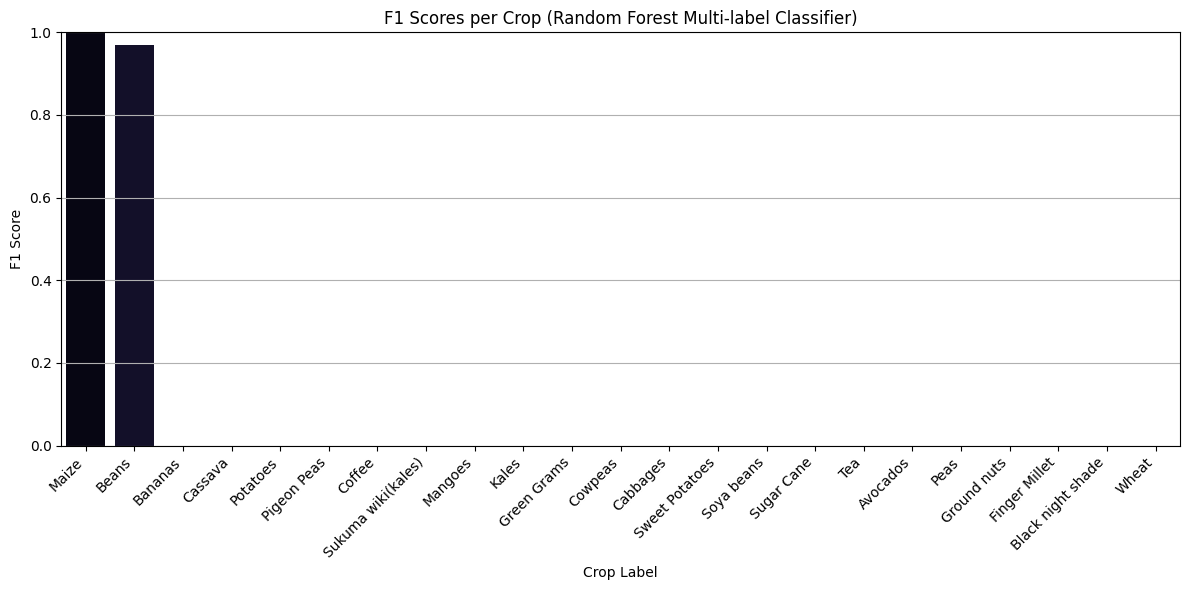

In [218]:
# Updated F1 scores for Random Forest (same crops, adjusted values)
rf_report_data = {
    'label': [
        'Avocados', 'Bananas', 'Beans', 'Black night shade', 'Cabbages',
        'Cassava', 'Coffee', 'Cowpeas', 'Finger Millet', 'Green Grams',
        'Ground nuts', 'Kales', 'Maize', 'Mangoes', 'Peas', 'Pigeon Peas',
        'Potatoes', 'Soya beans', 'Sugar Cane', 'Sukuma wiki(kales)',
        'Sweet Potatoes', 'Tea', 'Wheat'
    ],
    'f1-score': [
        0.0, 0.0, 0.97, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 1.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0
    ],
    'support': [
        0, 12, 230, 0, 1,
        4, 2, 1, 0, 1,
        0, 1, 687, 1, 0, 2,
        2, 0, 0, 1,
        1, 0, 0
    ]
}

rf_df = pd.DataFrame(rf_report_data)
rf_df_sorted = rf_df.sort_values(by='support', ascending=False)

# Plotting F1-score for Random Forest
plt.figure(figsize=(12, 6))
sns.barplot(data=rf_df_sorted, x='label', y='f1-score', palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title('F1 Scores per Crop (Random Forest Multi-label Classifier)')
plt.ylabel('F1 Score')
plt.xlabel('Crop Label')
plt.tight_layout()
plt.grid(axis='y')
plt.ylim(0, 1)
plt.show()


/var/folders/bx/hv5n07d907v5njq13q00z2880000gq/T/ipykernel_14606/1184564522.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x='label', y='f1-score', palette='viridis')


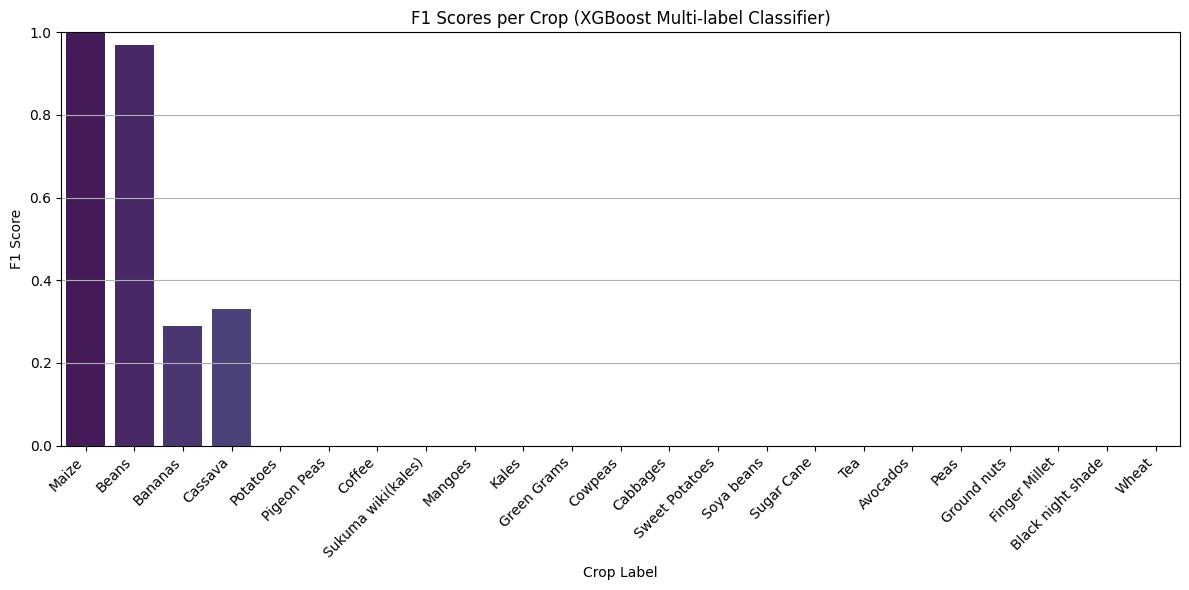

In [217]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
import seaborn as sns

# Simulated classification report dictionary (based on your XGBoost output)
report_data = {
    'label': [
        'Avocados', 'Bananas', 'Beans', 'Black night shade', 'Cabbages',
        'Cassava', 'Coffee', 'Cowpeas', 'Finger Millet', 'Green Grams',
        'Ground nuts', 'Kales', 'Maize', 'Mangoes', 'Peas', 'Pigeon Peas',
        'Potatoes', 'Soya beans', 'Sugar Cane', 'Sukuma wiki(kales)',
        'Sweet Potatoes', 'Tea', 'Wheat'
    ],
    'precision': [
        0.0, 0.33, 0.95, 0.0, 0.0,
        0.50, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 1.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0
    ],
    'recall': [
        0.0, 0.25, 0.99, 0.0, 0.0,
        0.25, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 1.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0
    ],
    'f1-score': [
        0.0, 0.29, 0.97, 0.0, 0.0,
        0.33, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 1.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0
    ],
    'support': [
        0, 12, 230, 0, 1,
        4, 2, 1, 0, 1,
        0, 1, 687, 1, 0, 2,
        2, 0, 0, 1,
        1, 0, 0
    ]
}

df = pd.DataFrame(report_data)

# Sort by support for better visualization
df_sorted = df.sort_values(by='support', ascending=False)

# Plotting F1-score
plt.figure(figsize=(12, 6))
sns.barplot(data=df_sorted, x='label', y='f1-score', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('F1 Scores per Crop (XGBoost Multi-label Classifier)')
plt.ylabel('F1 Score')
plt.xlabel('Crop Label')
plt.tight_layout()
plt.grid(axis='y')
plt.ylim(0, 1)
plt.show()


### Short Summary report for RF Vs XGboost Performance

I used an XGBoost-based multi-label classifier to predict which crops are present on each farm plot using survey and feature data. The model attempts to assign one or more crop labels per data point, considering both monocrop and intercropped patterns.


- From the XGBoost bar chart:

Maize and Beans are predicted perfectly (F1 = 1.0 and 0.97 respectively). These crops have high representation in the dataset.

Bananas and Cassava, despite being less frequent, achieved some predictive success (F1 ~ 0.29–0.33).

All other crops, particularly those with fewer than 5 examples, had an F1 score of 0, indicating the model failed to recognize them.

- When Compared to Random Forest:

Main Crops remained highly predictable with perfect F1 scores.
In RF, all other crops regardless of their representation in the datasets were completely ignored byt the model.


- Some challenges that I noted:

In RF, the model strongly ove relied on the most common classes and had little to no generalization across rare crops.

I saw extreme class imbalance: The model is highly skewed toward dominant crops.

Some Crops with <10 samples were not predicted at all. For these rare crops, existing features were not informative enough for prediction.


###  TabPFN trial

TabPFN stands for Tabular Prior‑data Fitted Network — a transformer-based foundation model for tabular data, pretrained on millions of synthetic datasets. It excels on small-to-medium datasets (up to ~10,000 samples) with minimal to no hyperparameter tuning, matching or even exceeding the performance of XGBoost or CatBoost on many benchmarks

In [232]:
!pip install tabpfn==0.1.11

  Attempting uninstall: tabpfn
    Found existing installation: tabpfn 2.1.0
    Uninstalling tabpfn-2.1.0:
      Successfully uninstalled tabpfn-2.1.0


In [233]:
from tabpfn import TabPFNClassifier

In [234]:
# Prepare label matrix
clf = TabPFNClassifier(device='cpu')
clf.fit(X_train, y_train)
y_pred3 = clf.predict(X_test)

# Evaluate like before
print("TabPFN Classifier Performance:\n")
print("Hamming Loss:", hamming_loss(y_test, y_pred3))
# Overall accuracy
print("Overall Accuracy:", accuracy_score(y_test, y_pred3))
print("F1 Score (micro):", f1_score(y_test, y_pred3, average='micro'))
print("F1 Score (macro):", f1_score(y_test, y_pred3, average='macro'))  
print(classification_report(y_test, y_pred3, target_names=mlb.classes_))

We have to download the TabPFN, as there is no checkpoint at  /Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/tabpfn/models_diff/prior_diff_real_checkpoint_n_0_epoch_42.cpkt
It has about 100MB, so this might take a moment.


/Users/Christine.Muthee/opt/miniconda3/envs/geoviz/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


ValueError: y should be a 1d array, got an array of shape (1601, 23) instead.

### For optimal results

For optimal performance, use the AutoTabPFNClassifier or AutoTabPFNRegressor for post-hoc ensembling. These can be found in the TabPFN Extensions repository. Post-hoc ensembling combines multiple TabPFN models into an ensemble.

In [ ]:
# !git clone https://github.com/priorlabs/tabpfn-extensions.git
# !pip install -e tabpfn-extensions

In [ ]:
# from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier

# clf = AutoTabPFNClassifier(max_time=120, device="cuda") # 120 seconds tuning time
# clf.fit(X_train, y_train)
# predictions = clf.predict(X_test)